In [ ]:
import tensorflow as tf
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import shutil
from tqdm import tqdm

# Paths
source_dir = "/content/drive/MyDrive/Final_push3.0"   # change this
output_dir = "/content/drive/MyDrive/split_data69.0"

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

random.seed(42)

# Create output folders
for split in ["train", "val", "test"]:
    for class_name in os.listdir(source_dir):
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# Split images
for class_name in tqdm(os.listdir(source_dir)):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "train", class_name, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "val", class_name, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "test", class_name, img)
        )

print("✅ Dataset split completed!")

100%|██████████| 11/11 [01:47<00:00,  9.75s/it]

✅ Dataset split completed!


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8
SEED = 42

TRAIN_DIR = "/content/drive/MyDrive/split_data69.0/train"
VAL_DIR   = "/content/drive/MyDrive/split_data69.0/val"
TEST_DIR  = "/content/drive/MyDrive/split_data69.0/test"

# Load datasets
train_ds_temp = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
).repeat() # IMPORTANT: Repeat to prevent running out of data

val_ds_temp = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_temp = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Extract class names
class_names = train_ds_temp.class_names

# Calculate steps per epoch manually for repeated dataset
train_sample_count = len(tf.data.experimental.get_cardinality(train_ds_temp.unbatch()))
steps_per_epoch = train_sample_count // BATCH_SIZE

validation_sample_count = len(tf.data.experimental.get_cardinality(val_ds_temp.unbatch()))
validation_steps = validation_sample_count // BATCH_SIZE


print("Final classes:", class_names)
num_classes = len(class_names)
print("Number of classes:", num_classes)

print(f"Estimated training samples: {train_sample_count}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Now add prefetch
train_ds = train_ds_temp.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_temp.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_temp.prefetch(tf.data.AUTOTUNE)

# Enhanced data augmentation - ALL from tf.keras.layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

Found 1479 files belonging to 11 classes.
Original classes found: ['BRIDGE', 'CLEAN_CRACK', 'CLEAN_LAYER', 'CLEAN_VIA', 'CMP', 'CRACK', 'LER', 'OPEN', 'OTHERS', 'PARTICLE', 'VIA']
Found 313 files belonging to 11 classes.
Found 327 files belonging to 11 classes.
Final classes: ['BRIDGE', 'CLEAN_CRACK', 'CLEAN_LAYER', 'CLEAN_VIA', 'CMP', 'CRACK', 'LER', 'OPEN', 'OTHERS', 'PARTICLE', 'VIA']
Number of classes: 11


In [ ]:
# ============================================================
# HELPER: Evaluate a phase ─ confusion matrix + per-class accuracy
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_phase(model, dataset, class_names, phase_name="Phase", save_prefix="cm"):
    """Run model over `dataset` and print confusion matrix + per-class accuracy."""
    all_preds, all_labels = [], []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    overall_acc = np.mean(all_preds == all_labels)

    print("\n" + "="*60)
    print(f"  {phase_name}  —  EVALUATION ON VALIDATION SET")
    print("="*60)
    print(f"Overall Accuracy : {overall_acc:.4f}  ({overall_acc*100:.2f}%)")
    print(f"Total Samples    : {len(all_labels)}")

    # ── Per-class accuracy ──────────────────────────────────────
    print("\nPer-Class Accuracy:")
    print(f"  {'Class':<15}  {'Correct':>7}  {'Total':>7}  {'Accuracy':>9}")
    print("  " + "-"*44)
    for idx, cls in enumerate(class_names):
        mask     = all_labels == idx
        total    = mask.sum()
        correct  = (all_preds[mask] == idx).sum() if total > 0 else 0
        acc      = correct / total if total > 0 else 0.0
        print(f"  {cls:<15}  {correct:>7}  {total:>7}  {acc:>8.2%}")

    # ── Classification report ───────────────────────────────────
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        zero_division=0
    ))

    # ── Confusion matrix ────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {phase_name}", fontsize=16, fontweight="bold")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fname = f"confusion_matrix_{save_prefix}.png"
    plt.savefig(fname, dpi=300)
    plt.show()
    print(f"✓ Confusion matrix saved as '{fname}'")
    print("="*60 + "\n")


In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

# Class weights - extract from BEFORE adding .repeat()
print("\nCalculating class weights...")
# Rebuild temp dataset without repeat for counting
train_ds_for_weights = (tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
.unbatch()
.filter(filter_excluded_classes)
.map(remap_labels)
.batch(BATCH_SIZE))

y_train = np.concatenate([y.numpy() for _, y in train_ds_for_weights])
print(f"Unique classes in training data: {np.unique(y_train)}")
print(f"Expected classes: {list(range(num_classes))}")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)



Calculating class weights...
Found 1479 files belonging to 11 classes.
Unique classes in training data: [ 0  1  2  3  4  5  6  7  8  9 10]
Expected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Class weights: {0: np.float64(0.572147001934236), 1: np.float64(6.722727272727273), 2: np.float64(1.841843088418431), 3: np.float64(4.4818181818181815), 4: np.float64(0.5949316170555109), 5: np.float64(0.5443503864556496), 6: np.float64(1.5278925619834711), 7: np.float64(0.7113997113997114), 8: np.float64(1.2004870129870129), 9: np.float64(0.9814200398142005), 10: np.float64(1.102086438152012)}


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(



=== Phase 1: Training Head ===
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 37s 159ms/step - accuracy: 0.3307 - loss: 2.1473 - val_accuracy: 0.6294 - val_loss: 1.3008 - learning_rate: 0.0010
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 37s 136ms/step - accuracy: 0.5905 - loss: 1.3150 - val_accuracy: 0.6581 - val_loss: 1.1297 - learning_rate: 0.0010
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.6658 - loss: 1.0944 - val_accuracy: 0.7125 - val_loss: 1.0388 - learning_rate: 0.0010
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 30s 160ms/step - accuracy: 0.6749 - loss: 0.9850 - val_accuracy: 0.7125 - val_loss: 0.9817 - learning_rate: 0.0010
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 52s 219ms/step - accuracy: 0.7044 - loss: 0.8936 - val_accuracy: 0.7188 - val_loss: 0.9619 - learning_rate: 0.0010
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.7245 - loss: 0.8491 - val_accuracy: 0.7412 - val_loss: 0.9243 - learning_rate: 0.0010
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━

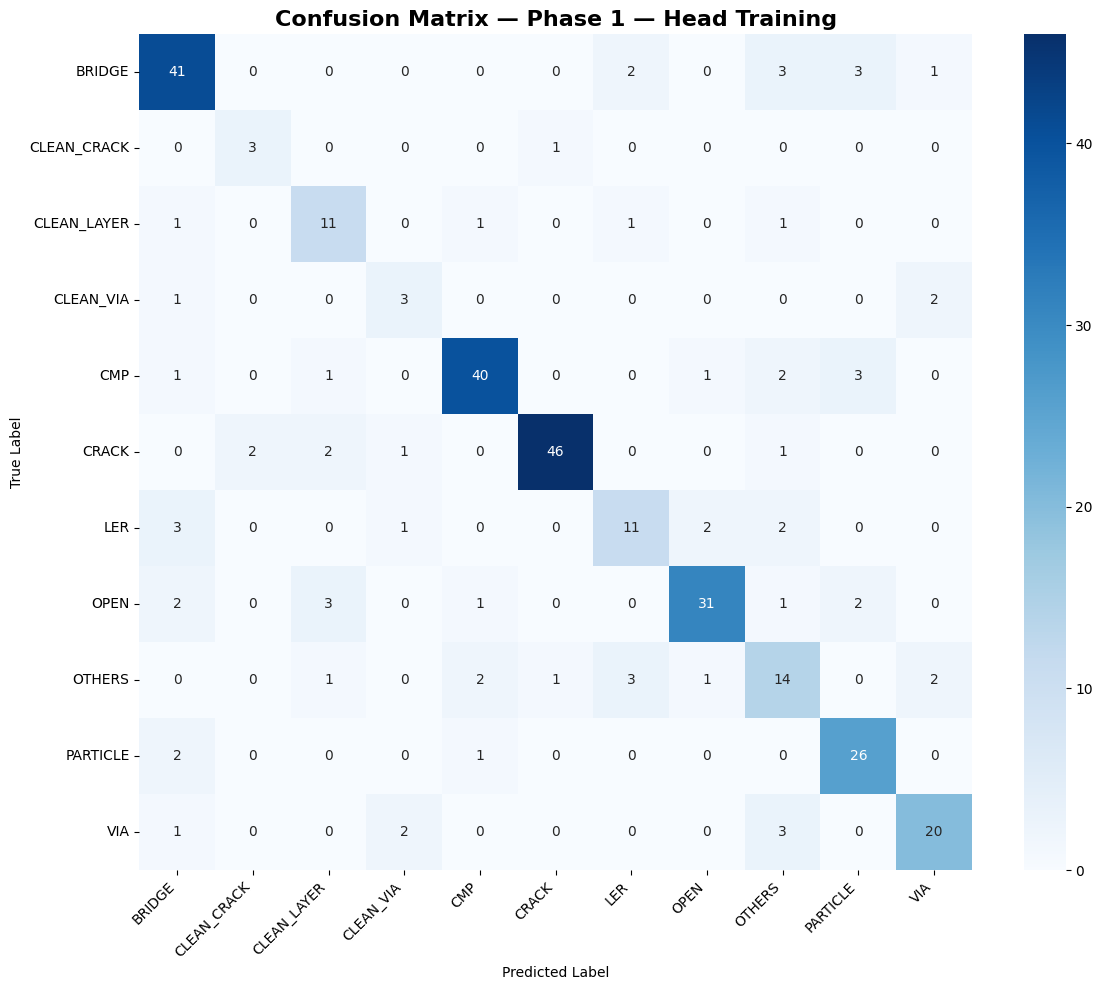

✓ Confusion matrix saved as 'confusion_matrix_phase1_head.png'



In [ ]:

EPOCHS_HEAD = 20

# ==============================
# DATA AUGMENTATION
# ==============================
data_augmentation = tf.keras.Sequential([
    #layers.RandomFlip("horizontal"),        # remove if orientation matters
    layers.RandomRotation(0.1),
], name="data_augmentation")



base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    alpha=0.75,          # 🔥 reduce channels
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# ==============================
# PHASE 1: TRAIN HEAD
# ==============================
print("\n=== Phase 1: Training Head ===")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5,
            patience=3
        )
    ]
)

# ==============================
# EVALUATE MODEL
# ==============================
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✓ FP32 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

model.save("mobilenetv3_fp32.keras")
# ──────────────────────────────────────────────────────────────
# Evaluate after Phase 1
# ──────────────────────────────────────────────────────────────
evaluate_phase(model, val_ds, class_names,
               phase_name="Phase 1 — Head Training",
               save_prefix="phase1_head")



=== Phase 2: Fine-tuning ===
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 52s 176ms/step - accuracy: 0.8555 - loss: 0.4610 - val_accuracy: 0.7827 - val_loss: 0.7820 - learning_rate: 1.0000e-05
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 32s 175ms/step - accuracy: 0.8617 - loss: 0.4284 - val_accuracy: 0.7796 - val_loss: 0.7829 - learning_rate: 1.0000e-05
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 34s 185ms/step - accuracy: 0.8878 - loss: 0.3891 - val_accuracy: 0.7764 - val_loss: 0.7789 - learning_rate: 1.0000e-05
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 39s 171ms/step - accuracy: 0.8741 - loss: 0.3987 - val_accuracy: 0.7796 - val_loss: 0.7782 - learning_rate: 1.0000e-05
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 31s 166ms/step - accuracy: 0.8894 - loss: 0.3803 - val_accuracy: 0.7796 - val_loss: 0.7768 - learning_rate: 1.0000e-05
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 30s 162ms/step - accuracy: 0.8779 - loss: 0.3667 - val_accuracy: 0.7796 - val_loss: 0.7757 - learning_rate: 1.0000e-05
Epoch 7/20
185/1

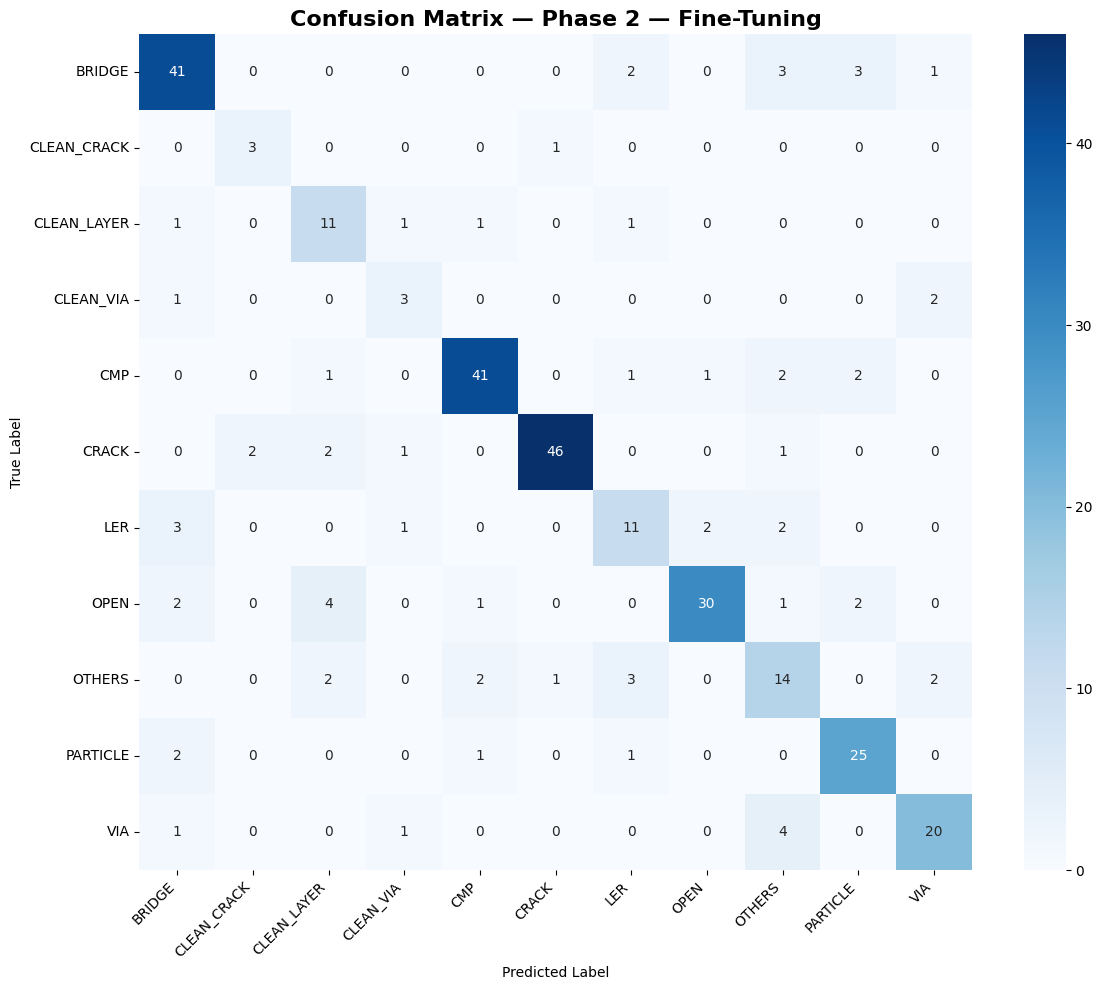

✓ Confusion matrix saved as 'confusion_matrix_phase2_finetune.png'



In [ ]:
EPOCHS_FINE = 20

print("\n=== Phase 2: Fine-tuning ===")

# Unfreeze base model
base_model.trainable = True

# Freeze first 80% instead (more stable)
fine_tune_at = int(len(base_model.layers) * 0.6)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 🔥 Keep BatchNorm layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 🔥 lower LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.3,
            patience=2
        )
    ]
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✓ Fine-tuned Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

model.save("mobilenetv3_finetuned.keras")
# ──────────────────────────────────────────────────────────────
# Evaluate after Phase 2
# ──────────────────────────────────────────────────────────────
evaluate_phase(model, val_ds, class_names,
               phase_name="Phase 2 — Fine-Tuning",
               save_prefix="phase2_finetune")


In [ ]:
import tensorflow as tf

# Load the Keras model (already loaded in the notebook, but good practice to explicitly load)
model = tf.keras.models.load_model(MODEL_PATH)

# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Define the path for the TFLite model
TFLITE_MODEL_PATH = '/content/mobilenetv3_finetuned.tflite'

# Save the TFLite model to a file
with open(TFLITE_MODEL_PATH, 'wb') as f:
    f.write(tflite_model)

print(f"✓ Keras model successfully converted and saved to: {TFLITE_MODEL_PATH}")